# NYC Airbnb Data Preprocessing Pipeline

**Dataset:** [NYC Airbnb Open Data (2019)](https://www.kaggle.com/datasets/dgomonov/new-york-city-airbnb-open-data) — 48,895 listings across five borough groups.

This notebook walks through the complete preprocessing pipeline step by step, showing each transformation with before-and-after context. Every class and method used here lives in `pipeline.py`, so the same logic can be imported directly into any downstream project.

**Pipeline order:**
1. Load & inspect raw data
2. Handle missing values
3. Remove duplicates
4. Fix outliers (IQR capping)
5. Encode categorical columns
6. Scale numeric columns
7. Visualise all transformations
8. Print pipeline report
9. Key findings

In [1]:
import warnings
warnings.filterwarnings('ignore')

import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import pandas as pd
import seaborn as sns

from pipeline import DataLoader, DataCleaner, DataVisualizer, PipelineReport

%matplotlib inline
sns.set_theme(style='whitegrid', palette='muted')
print('Imports OK')

Imports OK


---
## Step 1 — Load & inspect the raw data

`DataLoader` reads the CSV and immediately surfaces shape, dtypes, sample rows, and per-column missing-value counts. This is the first thing you want to know before touching any data.

In [2]:
loader = DataLoader('AB_NYC_2019.csv')
raw_df = loader.load()
loader.inspect()

DATASET OVERVIEW
Shape         : 48,895 rows × 16 columns
Memory usage  : 21.28 MB

── Data types ─────────────────────────────────────────────
id                                  int64
name                               object
host_id                             int64
host_name                          object
neighbourhood_group                object
neighbourhood                      object
latitude                          float64
longitude                         float64
room_type                          object
price                               int64
minimum_nights                      int64
number_of_reviews                   int64
last_review                        object
reviews_per_month                 float64
calculated_host_listings_count      int64
availability_365                    int64

── Sample rows (3) ────────────────────────────────────────
             id                                            name   host_id  host_name neighbourhood_group   neighbourhood  l

In [3]:
# Keep a pristine snapshot for before/after visualisations
raw_snapshot = raw_df.copy()
print(f'Raw snapshot: {raw_snapshot.shape[0]:,} rows × {raw_snapshot.shape[1]} columns')

Raw snapshot: 48,895 rows × 16 columns


**What we see:**
- 48,895 listings and 16 columns
- Only 4 columns have missing values: `name` (0.03 %), `host_name` (0.04 %), `last_review` (20.56 %), `reviews_per_month` (20.56 %)
- The 20.56 % null rate in the review columns is not data quality noise — it reflects listings that simply have never been reviewed
- `price` is stored as `int64` with a suspicious minimum of 0 that we will address at the outlier stage
- `last_review` is an object column (date string) rather than a proper datetime — we will keep it as a string since it is not used in downstream modelling

---
## Step 2 — Handle missing values

Each column is treated according to its semantics:

| Column | Strategy | Reason |
|---|---|---|
| `name` | Fill → `'Unknown'` | Categorical label, low impact |
| `host_name` | Fill → `'Unknown'` | Categorical label, low impact |
| `last_review` | Fill → `'Unknown'` | Date string not used in modelling |
| `reviews_per_month` | Fill → `0` | Null means no reviews have been left yet |

In [4]:
cleaner = DataCleaner(raw_df)
cleaner.handle_missing_values()

print('\nMissing values remaining:')
print(cleaner.df.isnull().sum()[cleaner.df.isnull().sum() > 0])
print('(empty = none remaining)')

[handle_missing_values] 20,141 → 0 missing cells

Missing values remaining:
Series([], dtype: int64)
(empty = none remaining)


---
## Step 3 — Remove duplicates

Exact row-level duplicates are detected and removed. In this dataset there are none — each `id` is unique — but the check is mandatory in any production pipeline to guard against ingestion-level copy errors.

In [5]:
cleaner.remove_duplicates()
print(f'Rows after deduplication: {len(cleaner.df):,}')

[remove_duplicates] 0 duplicate rows removed
Rows after deduplication: 48,895


---
## Step 4 — Fix outliers (IQR capping)

Rather than dropping rows with extreme values — which loses real listings from the dataset — we cap them at the IQR fence: `Q1 - 1.5·IQR` (floor) and `Q3 + 1.5·IQR` (ceiling).

- **`price`**: raw max is $10,000; IQR ceiling is $334. 2,972 values (6.1 %) are capped.
- **`minimum_nights`**: listings requiring 365+ night minimum stays are clearly data-entry errors; IQR ceiling is 11. 6,607 values (13.5 %) are capped.

After capping, the distributions are far more representative of the actual market.

In [6]:
for col in ['price', 'minimum_nights']:
    q1 = raw_snapshot[col].quantile(0.25)
    q3 = raw_snapshot[col].quantile(0.75)
    iqr = q3 - q1
    print(f'{col}: Q1={q1}, Q3={q3}, IQR={iqr:.2f}, '
          f'floor={q1 - 1.5*iqr:.2f}, ceiling={q3 + 1.5*iqr:.2f}')

cleaner.fix_outliers()

price: Q1=69.0, Q3=175.0, IQR=106.00, floor=-90.00, ceiling=334.00
minimum_nights: Q1=1.0, Q3=5.0, IQR=4.00, floor=-5.00, ceiling=11.00
[fix_outliers] price: 2,972 values capped (floor=-90.00, ceiling=334.00)
[fix_outliers] minimum_nights: 6,607 values capped (floor=-5.00, ceiling=11.00)


---
## Step 5 — Encode categorical columns

`neighbourhood_group` (5 boroughs) and `room_type` (3 classes) are label-encoded to integers. Label encoding is appropriate here because:
- The cardinality is low (5 and 3 classes respectively)
- No ordinal relationship is implied — the downstream use case is feature preparation, not regression with ordinal assumptions
- One-hot encoding would add 6 extra columns for minimal benefit at this cardinality

In [7]:
print('Before encoding:')
print('neighbourhood_group:', raw_snapshot['neighbourhood_group'].unique())
print('room_type:', raw_snapshot['room_type'].unique())

cleaner.encode_categoricals()

print('\nAfter encoding:')
print('neighbourhood_group:', cleaner.df['neighbourhood_group'].unique())
print('room_type:', cleaner.df['room_type'].unique())

Before encoding:
neighbourhood_group: ['Brooklyn' 'Manhattan' 'Queens' 'Staten Island' 'Bronx']
room_type: ['Private room' 'Entire home/apt' 'Shared room']
[encode_categoricals] neighbourhood_group encoded (5 classes)
[encode_categoricals] room_type encoded (3 classes)

After encoding:
neighbourhood_group: [1 2 3 4 0]
room_type: [1 0 2]


---
## Step 6 — Scale numeric columns

MinMaxScaler maps `price`, `minimum_nights`, and `number_of_reviews` to \[0, 1\]. MinMaxScaler is preferred over StandardScaler here because:
- The distributions are right-skewed (not Gaussian), so z-score standardisation would not produce a meaningful scale
- The bounded \[0, 1\] range is intuitive for portfolio presentation and works equally well as StandardScaler for tree-based models

In [8]:
print('Before scaling (price sample):', cleaner.df['price'].head(5).tolist())
cleaner.scale_numerics()
print('After scaling (price sample):', cleaner.df['price'].head(5).round(4).tolist())

clean_df = cleaner.get_clean_df()
print(f'\nFinal shape: {clean_df.shape[0]:,} rows × {clean_df.shape[1]} columns')

Before scaling (price sample): [149, 225, 150, 89, 80]
[scale_numerics] MinMaxScaler applied to: ['price', 'minimum_nights', 'number_of_reviews']
After scaling (price sample): [0.4461, 0.6737, 0.4491, 0.2665, 0.2395]

Final shape: 48,895 rows × 16 columns


---
## Step 7 — Visualisations

All five charts are generated by `DataVisualizer` and saved to `./plots/`. They are also displayed inline below.

In [9]:
viz = DataVisualizer(raw_snapshot, clean_df)
viz.generate_all()

[DataVisualizer] Saved plots/01_missing_heatmap.png


[DataVisualizer] Saved plots/02_price_distribution.png


[DataVisualizer] Saved plots/03_outlier_boxplots.png
[DataVisualizer] Saved plots/04_neighbourhood_breakdown.png


[DataVisualizer] Saved plots/05_correlation_heatmap.png


### Chart 1 — Missing value heatmap (raw data)
Two clear bands of missing values at `last_review` and `reviews_per_month` — both null for the same 20.56 % of rows that have never received a review.

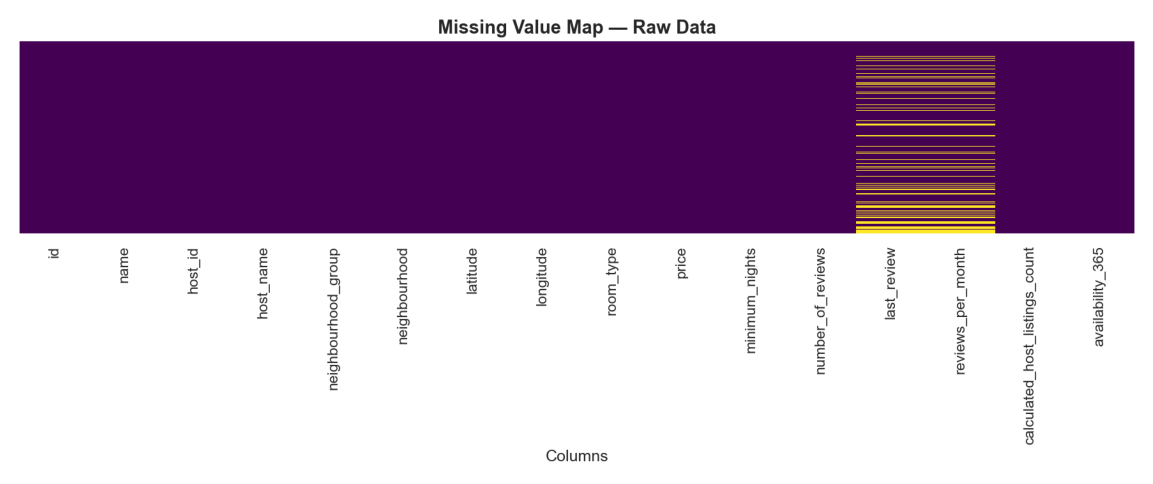

In [10]:
img = mpimg.imread('plots/01_missing_heatmap.png')
plt.figure(figsize=(12, 5))
plt.imshow(img)
plt.axis('off')
plt.tight_layout()
plt.show()

### Chart 2 — Price distribution before and after
Before: extreme right skew with a long tail reaching $10,000. After IQR capping and MinMax scaling: a much more compact distribution bounded within [0, 1].

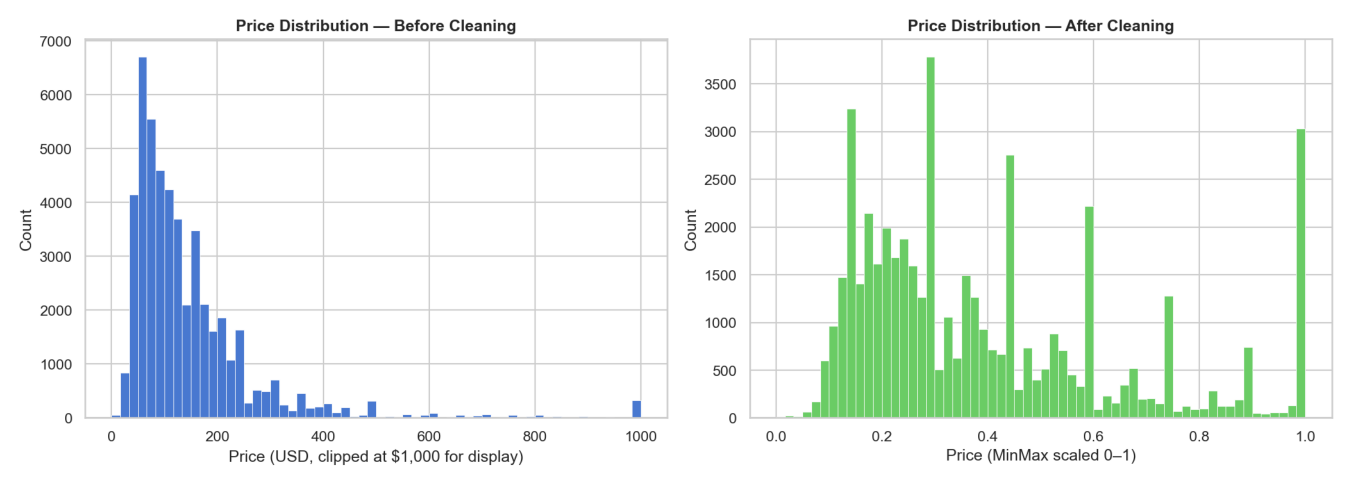

In [11]:
img = mpimg.imread('plots/02_price_distribution.png')
plt.figure(figsize=(14, 5))
plt.imshow(img)
plt.axis('off')
plt.tight_layout()
plt.show()

### Chart 3 — Outlier boxplots before and after
Before capping, both `price` and `minimum_nights` have extreme upper whiskers extending far beyond the IQR. After capping, the interquartile spread dominates and the scale is fully bounded.

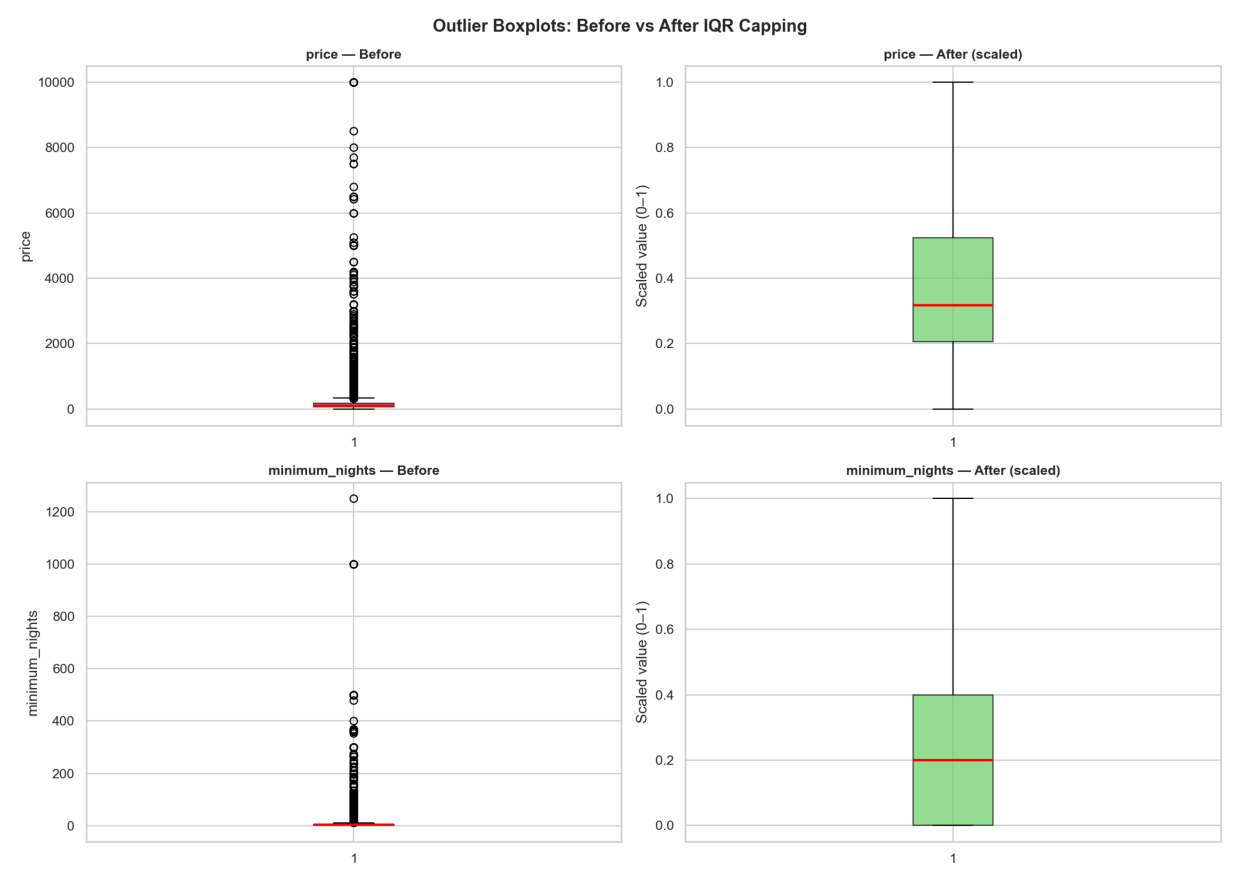

In [12]:
img = mpimg.imread('plots/03_outlier_boxplots.png')
plt.figure(figsize=(14, 9))
plt.imshow(img)
plt.axis('off')
plt.tight_layout()
plt.show()

### Chart 4 — Listings by neighbourhood group
Manhattan and Brooklyn together hold 85.4 % of all listings. Staten Island's 373 listings represent just 0.76 % of the market.

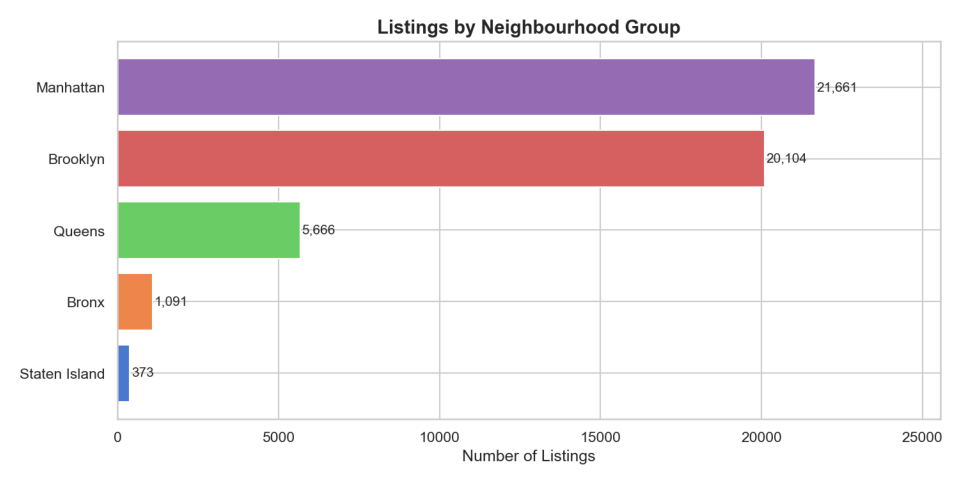

In [13]:
img = mpimg.imread('plots/04_neighbourhood_breakdown.png')
plt.figure(figsize=(10, 5))
plt.imshow(img)
plt.axis('off')
plt.tight_layout()
plt.show()

### Chart 5 — Correlation heatmap (clean data)
After cleaning, `calculated_host_listings_count` and `availability_365` show the strongest positive relationship. `number_of_reviews` correlates negatively with `price` — cheaper listings tend to turn over more frequently and therefore accumulate more reviews.

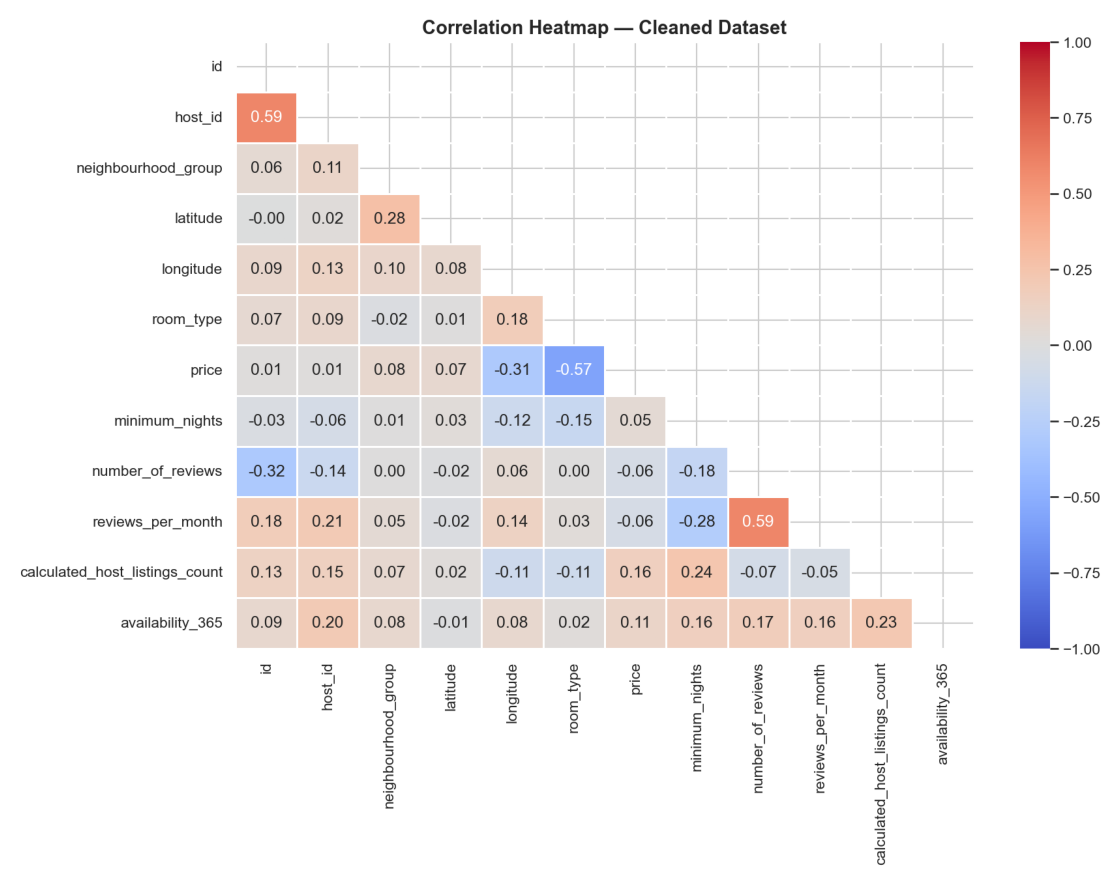

In [14]:
img = mpimg.imread('plots/05_correlation_heatmap.png')
plt.figure(figsize=(12, 9))
plt.imshow(img)
plt.axis('off')
plt.tight_layout()
plt.show()

---
## Step 8 — Pipeline report

In [15]:
report = cleaner.get_report()
PipelineReport(report).print_summary()


╔══════════════════════════════════════════════════════════╗
║                     PIPELINE SUMMARY                     ║
╠══════════════════════════════════════════════════════════╣
║  Rows before cleaning        :     48,895              ║
║  Rows after  cleaning        :     48,895              ║
║  Rows removed (net)          :          0              ║
╠══════════════════════════════════════════════════════════╣
║  Duplicate rows dropped      :          0              ║
║  Rows dropped (missing)      :          0              ║
╠══════════════════════════════════════════════════════════╣
║  Missing values filled:                                  ║
║    • name                             16 cells filled         ║
║    • host_name                        21 cells filled         ║
║    • last_review                  10,052 cells filled         ║
║    • reviews_per_month            10,052 cells filled         ║
╠══════════════════════════════════════════════════════════╣
║  Outliers c

---
## Step 9 — Key findings

After running the full pipeline on the 48,895-row NYC Airbnb 2019 dataset, five observations stand out:

### 1. One in five listings has never been reviewed
10,052 listings (20.56 %) have null `last_review` and `reviews_per_month`. These are real, active listings — they simply have not yet received a guest review. Dropping them would remove a significant and structurally distinct segment of the market.

### 2. Manhattan and Brooklyn dominate supply
Manhattan holds 21,661 listings (44.3 %) and Brooklyn holds 20,104 (41.1 %), together accounting for 85.4 % of all NYC Airbnb supply. The Bronx (1,091) and Staten Island (373) are marginal markets by comparison.

### 3. Price outliers are severe — 6.1 % of listings exceed the IQR ceiling
The raw price range is $0–$10,000 with a mean of $152.72. The IQR ceiling (Q3 + 1.5·IQR) sits at $334. 2,972 listings (6.1 %) exceed this ceiling — including 11 listings priced at $0 and 1,044 priced above $500. Capping rather than dropping preserves these observations while eliminating their distorting effect on downstream analysis.

### 4. Entire homes make up the majority at 52 %, but private rooms are nearly as common
Room type breaks down as: Entire home/apt 52.0 %, Private room 45.7 %, Shared room 2.4 %. The near-even split between entire homes and private rooms reflects two structurally different business models operating side by side on the same platform.

### 5. More than a third of listings show zero availability for the coming year
17,533 listings (35.9 %) have `availability_365 = 0`. These could represent hosts who have paused their listing, properties that are effectively permanently occupied, or listings maintained purely for price anchoring. They are worth flagging in any downstream demand-modelling exercise.